In [1]:
import ee
import ee.deserializer
import geemap
import json
import rasterio as rio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.colors as mcol
import contextily as cx
import rasterio.plot as rio_plot

import os

from afolu.assets.constants import LABEL_LIST
from pathlib import Path
import pandas as pd

c:\Users\lain\Documents\AFOLU\.venv\Lib\site-packages\geemap\conversion.py:23: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
ee.Initialize(project="ee-ursa-test")

In [3]:
ZONE = "PER+Coronel Portillo"

In [4]:
data_path = Path(os.environ["DATA_PATH"])
out_path = data_path / "generated"

In [5]:
proj = ee.Projection('PROJCS["South_America_Albers_Equal_Area_Conic",GEOGCS["SAD69",DATUM["South_American_Datum_1969",SPHEROID["GRS 1967 Modified",6378160,298.25,AUTHORITY["EPSG","7050"]],AUTHORITY["EPSG","6618"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4618"]],PROJECTION["Albers_Conic_Equal_Area"],PARAMETER["latitude_of_center",-32],PARAMETER["longitude_of_center",-60],PARAMETER["standard_parallel_1",-5],PARAMETER["standard_parallel_2",-42],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["ESRI","102033"]]')

with open(out_path / "small" / "bbox" / "ee" / f"{ZONE}.json") as f:
    bbox = ee.deserializer.decode(json.load(f))

with open(out_path / "transition_label_map.json") as f:
    transition_label_map = json.load(f)

In [6]:
wanted_cols = [f"emission_co2e_co2_lndu_conversion_{start}_to_{end}" for start in LABEL_LIST for end in LABEL_LIST] + ["time_period"]
wanted_cols_forests = [f"emission_co2e_co2_frst_sequestration_{t}" for t in ["primary", "secondary", "mangroves"]] + ["time_period"]

In [7]:
df_emissions = (
    pd.read_csv(out_path / "small" / "emissions" / f"{ZONE}.csv", usecols=wanted_cols)
    .assign(time_period=lambda df: df["time_period"].astype(int) + 2000)
    .query("time_period <= 2022")
    .set_index("time_period")
    .sort_index()
)

df_emissions_forests = (
    pd.read_csv(out_path / "small" / "emissions" / f"{ZONE}.csv", usecols=wanted_cols_forests)
    .assign(time_period=lambda df: df["time_period"].astype(int) + 2000)
    .set_index("time_period")
    .query("time_period <= 2022")
    .sort_index()
    .rename(columns={
        "emission_co2e_co2_frst_sequestration_primary": "forests_primary",
        "emission_co2e_co2_frst_sequestration_secondary": "forests_secondary",
        "emission_co2e_co2_frst_sequestration_mangroves": "forests_mangroves"
    })
)

In [8]:
df_area = (
    pd.read_csv(out_path / "small" / "area" / "table_merged" / f"{ZONE}.csv")
    .set_index("label")
    .transpose()
    .reset_index(names="time_period")
    .assign(time_period=lambda df: df["time_period"].astype(int) + 2000)
    .set_index("time_period")
    .sort_index()
    .multiply(10_000)
)

In [9]:
sequestration_per_meter_forests = (
    df_emissions_forests
    .divide(df_area.filter(like="forests"))
)

In [10]:
for year in range(2000, 2022):
    fpath = Path(f"./downloads/{year}_{year + 1}.tif")
    if fpath.exists():
        continue

    with open(out_path / "small" / "transition" / "raster" / f"{year}_{year + 1}" / f"{ZONE}.json") as f:
        raster = ee.deserializer.decode(json.load(f))

    geemap.download_ee_image(raster, fpath, region=bbox, scale=30, crs=proj)

In [11]:
total = []
for year in range(2000, 2022):
    df_trans = pd.read_csv(out_path / "small" / "transition" / "table_fixed" / f"{year}_{year + 1}" / f"{ZONE}.csv").set_index("start")

    emissions_temp = (
        df_emissions
        .loc[year]
        .rename("value")
        .reset_index()
        .assign(
            index=lambda df: df["index"].str.replace("emission_co2e_co2_lndu_conversion_", ""),
            start=lambda df: df["index"].str.split("_to_").str[0],
            end=lambda df: df["index"].str.split("_to_").str[1],
        )
        .drop(columns=["index"])
        .pivot_table(index="start", columns="end", values="value")
    )

    emissions_per_meter = (
        emissions_temp
        .divide(df_trans)
    )

    with rio.open(f"./downloads/{year}_{year + 1}.tif") as ds:
        data = ds.read(1)
        profile = ds.profile

    data_contrib = np.zeros_like(data, dtype=np.float64)
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            start, end = transition_label_map[str(data[i, j])]
            data_contrib[i, j] = emissions_per_meter.loc[start, end] * 900

            for forest_label in ["forests_primary", "forests_secondary", "forests_mangroves"]:
                if start == forest_label:
                    data_contrib[i, j] += sequestration_per_meter_forests.loc[year, forest_label] * 900

    data_contrib[data_contrib == 0] = np.nan
    total.append(data_contrib)

total = np.nansum(total, axis=0)
total[total == 0] = np.nan

In [12]:
profile["dtype"] = "float64"
profile["nodata"] = np.nan
with rio.open("./test_contrib.tif", "w", **profile) as dst:
    dst.write(total, 1)

CPLE_AppDefinedError: Deleting ./test_contrib.tif failed: Permission denied

In [ ]:
temp = total[~np.isnan(total)]
vmin = np.quantile(temp, 0.02)
vmax = np.quantile(temp, 0.98)

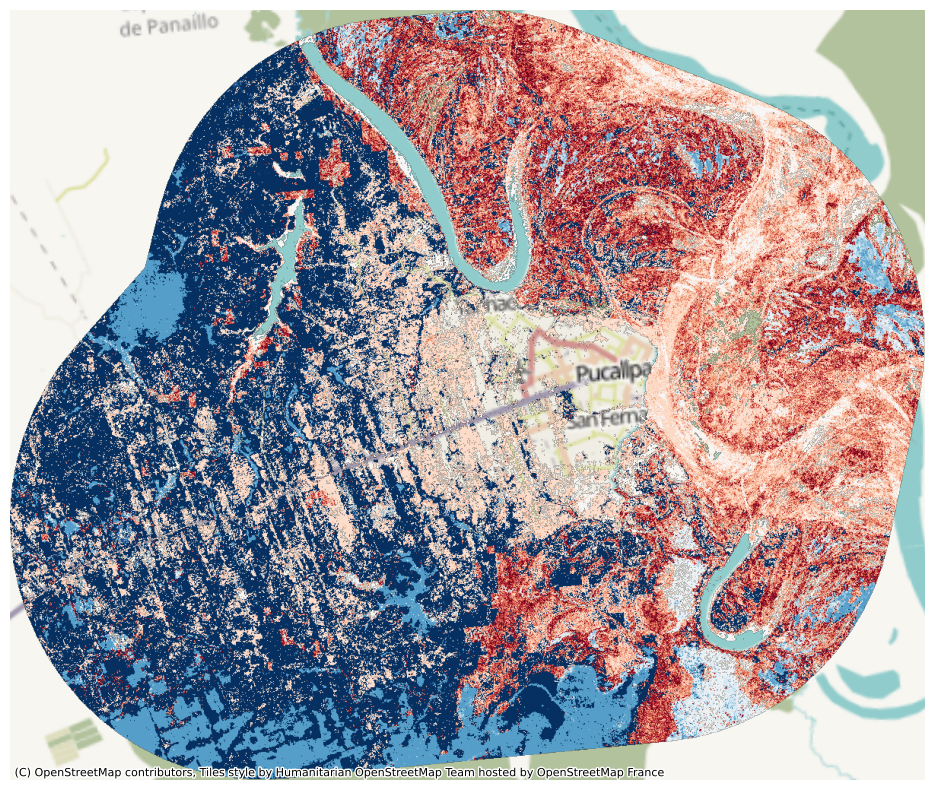

In [86]:
norm = mcol.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)
fig, ax = plt.subplots(figsize=(14, 8))
ax = rio_plot.show(total, ax=ax, cmap="RdBu_r", norm=norm, transform=profile["transform"])
ax.axis("off")
cx.add_basemap(ax, crs=str(profile["crs"]), zoom=11)
ax = rio_plot.show(total, ax=ax, cmap="RdBu_r", norm=norm, transform=profile["transform"])
fig.tight_layout()